In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df, title, method='spearman'):
    """
    Plots a correlation matrix for the given DataFrame.

    Parameters:
    df (pd.DataFrame): The input DataFrame for which to plot the correlation matrix.
    title (str): The title of the plot.

    Returns:
    None: Displays the correlation matrix plot.
    """
    # Calculate the correlation matrix
    corr_matrix = df.corr(method=method)

    # Set up the matplotlib figure
    plt.figure(figsize=(10, 8))

    # Draw the heatmap with seaborn
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)

    # Set the title of the plot
    plt.title(title)

    # Show the plot
    plt.show()

df_abs_2024 = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024\predictions_2024.parquet")
df_siam_2024 = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024_siam\predictions_2024.parquet")
df_siam_2016 = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-16siam\predictions_2016.parquet")

plot_correlation_matrix(df_siam_2024[["Rel_Score", "predicted_value"]], "Spearman Correlation Matrix - Siamese model 2024 - all tracts")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Working Papers\\NY State Aerial Imagery Prototype\\ny_state_aerial_imagery_prototype\\results\\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-16siam\\predictions_2016.parquet'

In [22]:
df_abs_2024.groupby("GEOID").agg({"Rel_Score": "mean", "predicted_value": "mean"}).corr()

,Rel_Score,predicted_value
Rel_Score,1.000000,0.749955
predicted_value,0.749955,1.000000


(-3.0, 3.0)

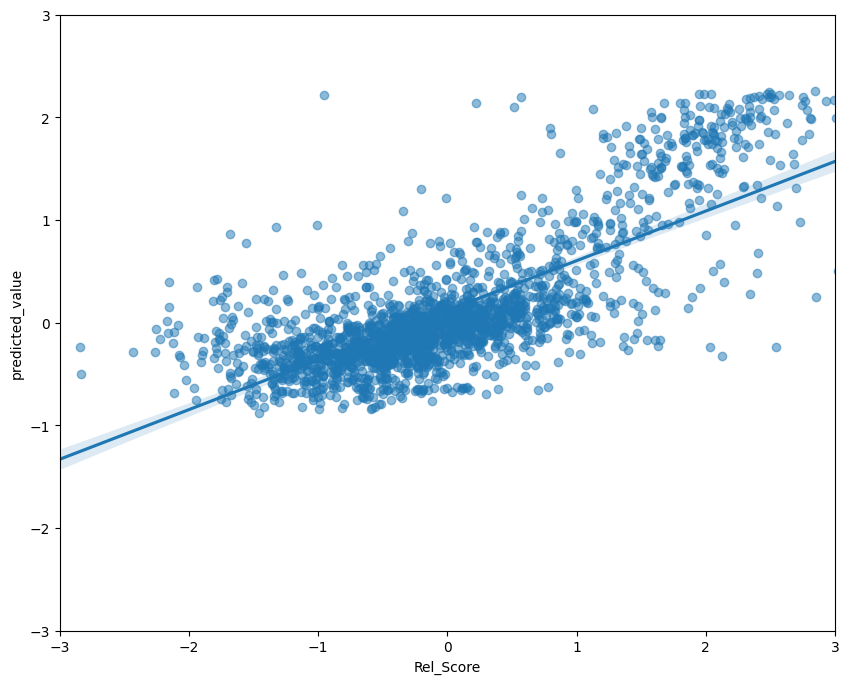

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.regplot(x="Rel_Score", y="predicted_value", data=df_abs_2024.groupby("GEOID").agg({"Rel_Score": "mean", "predicted_value": "mean"}), scatter_kws={'alpha':0.5}, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)